In [24]:
import pandas as pd 
import numpy as np
import re
import seaborn as sns

import scikit_posthocs as sp
from scipy.stats import friedmanchisquare
from matplotlib import pyplot as plt



In [25]:
import sys 
sys.path.append('../source')

In [26]:


def extraire_donnees_vers_tableau(nom_fichier):
    with open(nom_fichier, 'r') as f:
        contenu = f.read()


    blocs = contenu.strip().split("Algorithm:")[1:]
    
    liste_resultats = []
    
    for bloc in blocs:
        lignes = bloc.strip().split('\n')
        nom_algo = lignes[0].strip()
        
        parametres = {}
        for ligne in lignes[1:]:
            if ':' in ligne:
                cle, valeur = ligne.split(':', 1)
                cle = cle.strip()
                valeur = valeur.strip()
                
                if cle not in ['File name', 'ROC', 'Running time']:
                    parametres[cle] = valeur
        
        str_params = ", ".join([f"{k}: {v}" for k, v in parametres.items()])
        
        liste_resultats.append({
            "Algorithm": nom_algo,
            "Parameters": str_params
        })

    df = pd.DataFrame(liste_resultats)
    
    df = df.drop_duplicates().reset_index(drop=True)
    
    return df

try:
    nom_du_fichier = '../result'
    tableau_final = extraire_donnees_vers_tableau(nom_du_fichier)
    
    #print("Tableau des Algorithmes et Paramètres :")
    print(tableau_final.to_markdown(index=False))
    
    #tableau_final.to_latex("results/parametres_algos.tex", index=False)
    
except FileNotFoundError:
    print("Erreur : Le fichier n'a pas été trouvé. Vérifiez le nom du fichier.")

| Algorithm   | Parameters                                                                |
|:------------|:--------------------------------------------------------------------------|
| LODA        | num_bins: 10, num_random_cuts: 100                                        |
| xStream     | num_components: 100, n_chains: 100, depth: 25, window_size: 25            |
| HSTree      | window_size: 100, num_trees: 25, max_depth: 15                            |
| RSHash      | sampling_points: 1000, decay: 0.015, num_components: 100, num_hash_fns: 1 |
| IForestASD  | window_size: 2048                                                         |
| LODA        | num_bins: 20, num_random_cuts: 50                                         |
| LODA        | num_bins: 5, num_random_cuts: 200                                         |
| xStream     | num_components: 50, n_chains: 50, depth: 15, window_size: 50              |
| xStream     | num_components: 200, n_chains: 200, depth: 35, window_size: 10  

In [27]:
file_path = "../result"

with open(file_path, 'r') as file:
    content = file.read()

In [28]:

def extraire_donnees_completes(nom_fichier):
    try:
        with open(nom_fichier, 'r', encoding='utf-8') as f:
            contenu = f.read()
    except FileNotFoundError:
        return "Erreur : Le fichier '{}' est introuvable.".format(nom_fichier)

    blocs = re.split(r'\n(?=Algorithm:)', contenu.strip())
    
    liste_resultats = []

    for bloc in blocs:
        lignes = bloc.strip().split('\n')
        info_entree = {}
        
        for ligne in lignes:
            if ':' in ligne:
                cle, valeur = ligne.split(':', 1)
                cle = cle.strip()
                valeur = valeur.strip()
       
                try:
                    if '.' in valeur:
                        valeur = float(valeur)
                    else:
                        valeur = int(valeur)
                except ValueError:
                    pass 
                
                info_entree[cle] = valeur
        
        if info_entree:
            liste_resultats.append(info_entree)

    # Création du DataFrame
    df = pd.DataFrame(liste_resultats)
    

    col_file = 'File name'
    col_roc = 'ROC'
    col_time = 'Running time'

    # S'assurer que les colonnes critiques existent
    for col in [col_file, col_roc, col_time]:
        if col not in df.columns:
            df[col] = None

    # 4. Trouver le meilleur algo par fichier
    # Tri : ROC descendant, puis Temps ascendant
    df_sorted = df.sort_values(by=[col_file, col_roc, col_time], 
                               ascending=[True, False, True])
    
    # On garde la meilleure ligne pour chaque fichier
    meilleurs = df_sorted.groupby(col_file).first().reset_index()
    
    return meilleurs


In [29]:
import re

def generer_rapport_final(nom_fichier):
    try:
        with open(nom_fichier, 'r', encoding='utf-8') as f:
            contenu = f.read()
    except FileNotFoundError:
        return f"Erreur : Le fichier '{nom_fichier}' est introuvable."

    blocs = re.split(r'\n(?=Algorithm:)', contenu.strip())
    
    data = []
    for bloc in blocs:
        algo = re.search(r'Algorithm:\s*(.*)', bloc)
        file = re.search(r'File name:\s*(.*)', bloc)
        roc = re.search(r'ROC:\s*([\d.]+)', bloc)
        time = re.search(r'Running time:\s*([\d.]+)', bloc)

        h_params = re.findall(r'^([\w_]+):\s*([\d.]+)', bloc, re.MULTILINE)
        params_dict = {k: v for k, v in h_params if k not in ['ROC', 'Running_time']}

        if algo and file and roc:
            data.append({
                'Algorithm': algo.group(1).strip(),
                'Dataset': file.group(1).strip(),
                'ROC': float(roc.group(1)),
                'Time': float(time.group(1)) if time else 0.0,
                'Params': params_dict
            })

    # 2. Transformation en DataFrame
    df = pd.DataFrame(data)


    df = df.sort_values(by=['Dataset', 'ROC', 'Time'], ascending=[True, False, True])

    df['Display'] = df.apply(lambda x: f"{x['ROC']:.4f} ({x['Time']:.1f}s)", axis=1)

    # Pivotage
    pivot_roc = df.pivot_table(index='Dataset', columns='Algorithm', values='ROC', aggfunc='first')
    pivot_display = df.pivot_table(index='Dataset', columns='Algorithm', values='Display', aggfunc='first')
    

    def souligner_meilleur(row_name):
        rocs = pivot_roc.loc[row_name]
        displays = pivot_display.loc[row_name]
        max_roc = rocs.max()
        
        new_row = []
        for r, d in zip(rocs, displays):
            # On met en gras si c'est le max (et pas NaN)
            if r == max_roc and pd.notna(r):
                new_row.append(f"**{d}**")
            else:
                new_row.append(str(d) if pd.notna(d) else "N/A")
        return new_row

    # Construction du tableau final stylisé
    final_data = []
    for dataset in pivot_roc.index:
        final_data.append(souligner_meilleur(dataset))

    df_final = pd.DataFrame(final_data, index=pivot_roc.index, columns=pivot_roc.columns)
    
    
    return df_final, pivot_roc


In [30]:

nom_fichier = "../result"
tableau, pivot_roc = generer_rapport_final(nom_fichier)

if isinstance(tableau, pd.DataFrame):
    print(tableau.to_markdown())
    
   
else:
    print(tableau)

| Dataset                    | HSTree            | IForestASD          | LODA            | RSHash          | xStream              |
|:---------------------------|:------------------|:--------------------|:----------------|:----------------|:---------------------|
| COIL20_mix_sudden          | 0.9266 (1208.4s)  | **0.9565 (257.7s)** | 0.5001 (133.6s) | 0.9167 (178.0s) | 0.9521 (1829.8s)     |
| Ionosphere_shake_gradual   | 0.7318 (79.1s)    | **0.9823 (145.8s)** | 0.5000 (613.3s) | 0.7329 (218.6s) | 0.9233 (821.7s)      |
| Ionosphere_shake_sudden_2  | 0.7312 (98.8s)    | **0.9786 (158.9s)** | 0.5000 (192.9s) | 0.7343 (294.1s) | 0.9204 (1028.3s)     |
| S1                         | 0.8771 (632.9s)   | **0.9831 (39.1s)**  | 0.7246 (83.0s)  | 0.9682 (19.1s)  | 0.9560 (400.8s)      |
| S2                         | **0.6152 (0.7s)** | 0.6059 (25.2s)      | 0.5002 (32.9s)  | 0.5595 (28.4s)  | 0.5430 (122.2s)      |
| WOBC_shake_gradual_2       | 0.7305 (109.2s)   | 0.9278 (159.8s)     | 0.5

In [31]:
pivot_roc

Algorithm,HSTree,IForestASD,LODA,RSHash,xStream
Dataset,,,,,
COIL20_mix_sudden,0.9266,0.9565,0.5001,0.9167,0.9521
Ionosphere_shake_gradual,0.7318,0.9823,0.5000,0.7329,0.9233
Ionosphere_shake_sudden_2,0.7312,0.9786,0.5000,0.7343,0.9204
S1,0.8771,0.9831,0.7246,0.9682,0.9560
S2,0.6152,0.6059,0.5002,0.5595,0.5430
WOBC_shake_gradual_2,0.7305,0.9278,0.5000,0.7342,0.9771
WOBC_shake_sudden,0.7353,0.9432,0.5001,0.7361,0.9794
dermatology_shake_gradual,0.7447,0.9896,0.5000,0.7316,0.9950
dermatology_shake_sudden_2,0.7321,0.9850,0.5000,0.7130,0.9959


Friedman p-value : 0.0000


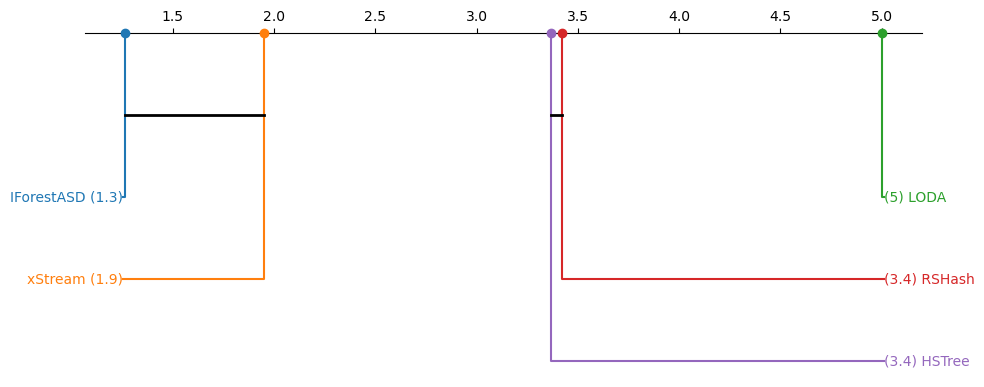

In [32]:

stat, p = friedmanchisquare(*[pivot_roc[col] for col in pivot_roc.columns])
print(f"Friedman p-value : {p:.4f}")

ranks = pivot_roc.rank(axis=1, ascending=False).mean()

sig_matrix = sp.posthoc_nemenyi_friedman(pivot_roc)

plt.figure(figsize=(10, 4))
sp.critical_difference_diagram(ranks, sig_matrix)
plt.tight_layout()
#plt.savefig("cd_diagram.png", dpi=150, bbox_inches="tight")
plt.show()

In [33]:
#pivot_roc.to_csv("results/pivot_roc_sota.csv", index=False)

/tmp/ipykernel_32291/3772444368.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=pivot_roc.columns, y=pivot_roc.mean(), palette="viridis")


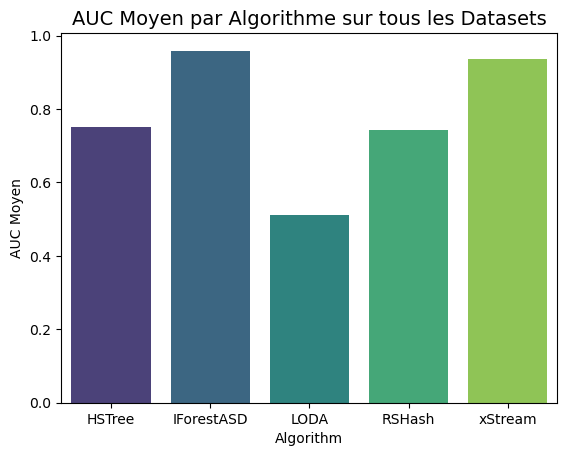

In [34]:
sns.barplot(x=pivot_roc.columns, y=pivot_roc.mean(), palette="viridis")
plt.title("AUC Moyen par Algorithme sur tous les Datasets", fontsize=14)
plt.ylabel("AUC Moyen")
plt.show()

In [41]:

nom_du_fichier = "../result"
df_final = extraire_donnees_completes(nom_du_fichier)


print(df_final.to_string(index=False))

#df_final.to_csv("synthese_performances.csv", index=False)

                 File name  Algorithm    ROC  Running time  num_bins  num_random_cuts  num_components  n_chains  depth  window_size  num_trees  max_depth  sampling_points  decay  num_hash_fns
         COIL20_mix_sudden IForestASD 0.9565      257.6550      20.0             50.0            50.0      50.0   15.0       1024.0       35.0       20.0           2000.0  0.020           1.0
  Ionosphere_shake_gradual IForestASD 0.9823      145.8133       5.0            200.0            50.0      50.0   15.0       1024.0       25.0       15.0           2000.0  0.020           1.0
 Ionosphere_shake_sudden_2 IForestASD 0.9786      158.8626      20.0             50.0            50.0      50.0   15.0       1024.0       25.0       15.0           2000.0  0.020           1.0
                        S1 IForestASD 0.9831       39.1305      20.0             50.0            50.0      50.0   15.0        200.0       35.0       20.0            500.0  0.010           2.0
                        S2     HSTree 0.

In [42]:

file = "../result"
tableau = generer_rapport_final(file)

if isinstance(tableau, pd.DataFrame):
    print(tableau.to_markdown())
    #tableau.to_latex("results/rapport_performance.tex", index=True, escape=False)
else:
    print(tableau)

(Algorithm                              HSTree           IForestASD  \
Dataset                                                              
COIL20_mix_sudden            0.9266 (1208.4s)  **0.9565 (257.7s)**   
Ionosphere_shake_gradual       0.7318 (79.1s)  **0.9823 (145.8s)**   
Ionosphere_shake_sudden_2      0.7312 (98.8s)  **0.9786 (158.9s)**   
S1                            0.8771 (632.9s)   **0.9831 (39.1s)**   
S2                          **0.6152 (0.7s)**       0.6059 (25.2s)   
WOBC_shake_gradual_2          0.7305 (109.2s)      0.9278 (159.8s)   
WOBC_shake_sudden               0.7353 (5.1s)      0.9432 (127.4s)   
dermatology_shake_gradual       0.7447 (4.4s)      0.9896 (144.7s)   
dermatology_shake_sudden_2   0.7321 (2012.5s)      0.9850 (250.5s)   
glass_shake_gradual_2           0.7481 (6.5s)  **0.9859 (156.2s)**   
glass_shake_sudden_2         0.7355 (2023.9s)  **0.9872 (154.9s)**   
mice_shake_gradual_2            0.7267 (6.1s)  **0.9996 (161.9s)**   
mice_shake_sudden  